In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import numpy as np
import urllib.request
import zipfile

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.20.0
Keras version: 3.13.2


In [11]:
########################################################################################################################
# PARAMETERS
########################################################################################################################

max_features = 10000  # number of words to consider as features
max_len = 500  # cut texts after this number of words (among top max_features most common words)
embedding_dim = 50
batch_size = 2048
init_lr = 1e-3

In [12]:
########################################################################################################################
# LOADING DATA
########################################################################################################################

print('Loading data...')
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

print('Pad sequences (samples x time)')
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('x_test shape:', y_test.shape)
print('x_train sample:', x_train[0])
print('y_train samples:', y_train[:10])

Loading data...
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
x_train shape: (25000, 500)
y_train shape: (25000,)
x_test shape: (25000, 500)
x_test shape: (25000,)
x_train sample: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0 

In [13]:
########################################################################################################################
# DOWNLOADING GLOVE 6B EMBEDDINGS
########################################################################################################################

# Download and unpack into project root
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "./glove.6B.zip"
glove_path = f'./glove.6B.{embedding_dim}d.txt'

if not os.path.exists(zip_path):
    print("Downloading Glove 6B embeddings...")
    urllib.request.urlretrieve(glove_url, zip_path)
    print("Finished.")

if not os.path.exists(glove_path):
    print("Unpacking embeddings...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./')

In [14]:
########################################################################################################################
# LOADING EMBEDDINGS
########################################################################################################################

embeddings_index = {}
f = open(glove_path, encoding="utf8")
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()
print('Found %s word vectors.' % len(embeddings_index))

embedding_matrix = np.zeros((max_features, embedding_dim))
word_index = tf.keras.datasets.imdb.get_word_index()
print("Found %s word indexes in IMDB set." % len(word_index))

cnt_skiped = 0
cnt_processed = 0
index_offset = 3 # Keras offset za IMDB zbog dodavanja specijalnih tokena <PAD>, <START> i <UNK>

for word, i in word_index.items():
    adjusted_index = i + index_offset # Usklađujemo indeks

    if adjusted_index < max_features:
        embedding_vector = embeddings_index.get(word)
        cnt_processed += 1
        if embedding_vector is not None:
            # Reči pronađene u embedding indexu dobijaju svoje vektore
            embedding_matrix[adjusted_index] = embedding_vector
    else:
        cnt_skiped += 1

print(cnt_processed, cnt_skiped)

Found 400000 word vectors.
Found 88584 word indexes in IMDB set.
9996 78588


In [15]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input((max_len,)))
model.add(tf.keras.layers.Embedding(max_features, embedding_dim))
model.add(tf.keras.layers.LSTM(64))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Setting embedding matrix
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False

optimizer = tf.keras.optimizers.Adam(learning_rate=init_lr)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.binary_crossentropy,
              metrics=[tf.keras.metrics.binary_accuracy])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,505 (2.02 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [16]:
########################################################################################################################
# TRAINING MODEL
########################################################################################################################

path = os.path.join(os.getcwd(), 'trained_model.keras')
save_model = tf.keras.callbacks.ModelCheckpoint(path, monitor='val_binary_accuracy', mode='max',
                                                verbose=1, save_best_only=True)

csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(os.getcwd(), 'training.csv'))

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', mode='max',
                                                  patience=20, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_binary_accuracy', mode='max',
                                                 factor=0.1, patience=10, verbose=1)

hist = model.fit(x_train, y_train,
                 epochs=1000,
                 batch_size=batch_size,
                 validation_data=(x_test, y_test),
                 shuffle=True,
                 callbacks=[save_model,
                            csv_logger,
                            early_stopping,
                            reduce_lr],
                 verbose=2)

model.save(path, include_optimizer=False)

Epoch 1/1000

Epoch 1: val_binary_accuracy improved from None to 0.58304, saving model to /content/trained_model.keras

Epoch 1: finished saving model to /content/trained_model.keras
13/13 - 4s - 325ms/step - binary_accuracy: 0.5201 - loss: 0.6995 - val_binary_accuracy: 0.5830 - val_loss: 0.6739 - learning_rate: 0.0010
Epoch 2/1000

Epoch 2: val_binary_accuracy improved from 0.58304 to 0.63548, saving model to /content/trained_model.keras

Epoch 2: finished saving model to /content/trained_model.keras
13/13 - 3s - 215ms/step - binary_accuracy: 0.5929 - loss: 0.6672 - val_binary_accuracy: 0.6355 - val_loss: 0.6389 - learning_rate: 0.0010
Epoch 3/1000

Epoch 3: val_binary_accuracy improved from 0.63548 to 0.69208, saving model to /content/trained_model.keras

Epoch 3: finished saving model to /content/trained_model.keras
13/13 - 3s - 224ms/step - binary_accuracy: 0.6754 - loss: 0.6177 - val_binary_accuracy: 0.6921 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 4/1000

Epoch 4: val_bina

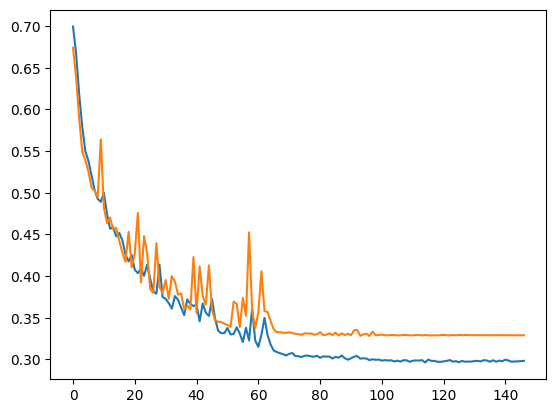

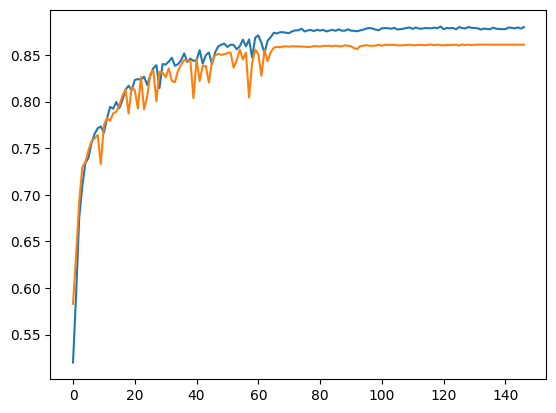

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - binary_accuracy: 0.8613 - loss: 0.3290
[0.32897505164146423, 0.8612800240516663]


In [17]:
########################################################################################################################
# EVALUATE TRAINED MODEL
########################################################################################################################

plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.show()

plt.clf()
plt.plot(hist.history['binary_accuracy'])
plt.plot(hist.history['val_binary_accuracy'])
plt.show()

eval = model.evaluate(x_test, y_test)
print(eval)

In [18]:
########################################################################################################################
# FINE-TUNING MODEL
########################################################################################################################

# Unlocking embedding layer
model.layers[0].trainable = True

optimizer = tf.keras.optimizers.Adam(learning_rate=0.1*init_lr)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.binary_crossentropy,
              metrics=[tf.keras.metrics.binary_accuracy])

path = os.path.join(os.getcwd(), 'finetuned_model.keras')
save_model = tf.keras.callbacks.ModelCheckpoint(path, monitor='val_binary_accuracy', mode='max',
                                                verbose=1, save_best_only=True)

csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(os.getcwd(), 'finetuning.csv'))

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', mode='max',
                                                  patience=20, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_binary_accuracy', mode='max',
                                                 factor=0.1, patience=10, verbose=1)

hist = model.fit(x_train, y_train,
                 epochs=1000,
                 batch_size=batch_size,
                 validation_data=(x_test, y_test),
                 shuffle=True,
                 callbacks=[save_model,
                            csv_logger,
                            early_stopping,
                            reduce_lr],
                 verbose=2)

model.save(path, include_optimizer=False)

Epoch 1/1000

Epoch 1: val_binary_accuracy improved from None to 0.86080, saving model to /content/finetuned_model.keras

Epoch 1: finished saving model to /content/finetuned_model.keras
13/13 - 5s - 352ms/step - binary_accuracy: 0.8728 - loss: 0.3064 - val_binary_accuracy: 0.8608 - val_loss: 0.3331 - learning_rate: 1.0000e-04
Epoch 2/1000

Epoch 2: val_binary_accuracy improved from 0.86080 to 0.86164, saving model to /content/finetuned_model.keras

Epoch 2: finished saving model to /content/finetuned_model.keras
13/13 - 5s - 376ms/step - binary_accuracy: 0.8789 - loss: 0.2979 - val_binary_accuracy: 0.8616 - val_loss: 0.3261 - learning_rate: 1.0000e-04
Epoch 3/1000

Epoch 3: val_binary_accuracy improved from 0.86164 to 0.86328, saving model to /content/finetuned_model.keras

Epoch 3: finished saving model to /content/finetuned_model.keras
13/13 - 3s - 233ms/step - binary_accuracy: 0.8807 - loss: 0.2923 - val_binary_accuracy: 0.8633 - val_loss: 0.3227 - learning_rate: 1.0000e-04
Epoch 4

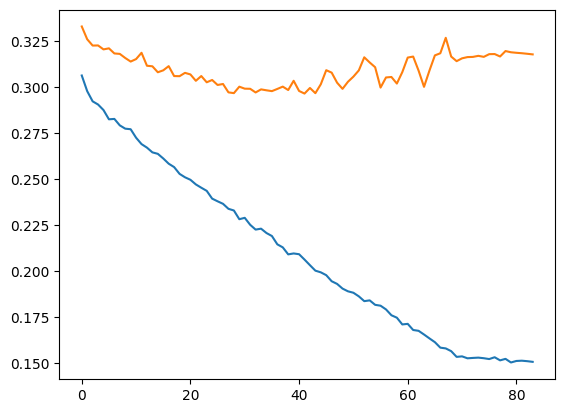

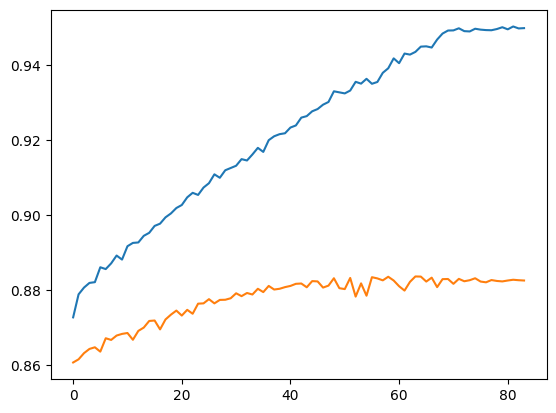

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - binary_accuracy: 0.8837 - loss: 0.3002
[0.30022844672203064, 0.883679986000061]


In [19]:
########################################################################################################################
# EVALUATE FINE-TUNED MODEL
########################################################################################################################

plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.show()

plt.clf()
plt.plot(hist.history['binary_accuracy'])
plt.plot(hist.history['val_binary_accuracy'])
plt.show()

eval = model.evaluate(x_test, y_test)
print(eval)